Dataset Loaded: (20, 5)

=== CORRELATION MATRIX ===
            avg_cost  avg_defect
avg_cost     1.00000    -0.02176
avg_defect  -0.02176     1.00000


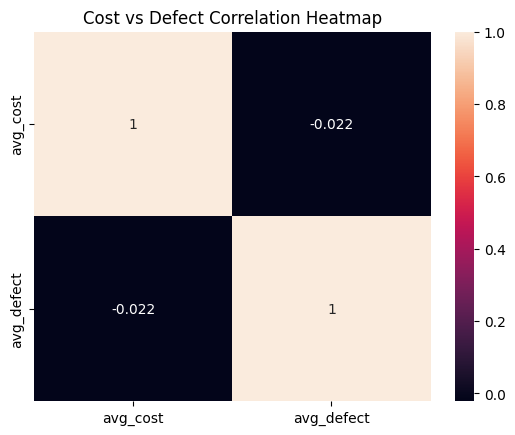

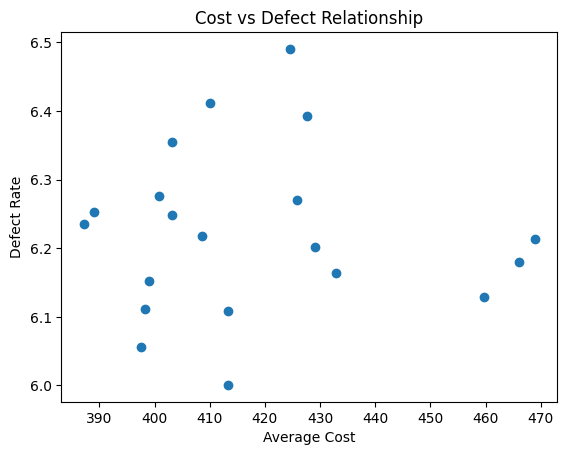


Inefficient Vendors: 3

Day 13 Analysis Completed Successfully


In [1]:
# Day 13 - Cost vs Defect Correlation Analysis
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ----------------------------------------------------------
# PATH SETUP
# ----------------------------------------------------------

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/vendor_performance.csv"

OUTPUT_DIR = PROJECT_ROOT / "03_processed_data"
VIS_DIR = PROJECT_ROOT / "04_visualizations"

OUTPUT_DIR.mkdir(exist_ok=True)
VIS_DIR.mkdir(exist_ok=True)

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. CORRELATION ANALYSIS
# ----------------------------------------------------------

correlation = df[["avg_cost", "avg_defect"]].corr()

print("\n=== CORRELATION MATRIX ===")
print(correlation)

# ----------------------------------------------------------
# 2. HEATMAP
# ----------------------------------------------------------

plt.figure()

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Cost vs Defect Correlation Heatmap")

plt.savefig(VIS_DIR / "correlation_heatmap.png")
plt.show()
plt.close()

# ----------------------------------------------------------
# 3. SCATTER PLOT
# ----------------------------------------------------------

plt.figure()

plt.scatter(
    df["avg_cost"],
    df["avg_defect"]
)

plt.xlabel("Average Cost")
plt.ylabel("Defect Rate")
plt.title("Cost vs Defect Relationship")

plt.savefig(VIS_DIR / "cost_vs_defect.png")
plt.show()
plt.close()

# ----------------------------------------------------------
# 4. DERIVED METRIC (IMPORTANT)
# Cost Efficiency per Defect
# ----------------------------------------------------------

df["cost_per_defect"] = df["avg_cost"] / (df["avg_defect"] + 0.0001)

# Higher = paying more per defect (bad)
# Lower = better cost-quality balance

# ----------------------------------------------------------
# 5. IDENTIFY INEFFICIENT VENDORS
# High cost + high defect
# ----------------------------------------------------------

avg_cost = df["avg_cost"].mean()
avg_defect = df["avg_defect"].mean()

inefficient = df[
    (df["avg_cost"] > avg_cost) &
    (df["avg_defect"] > avg_defect)
]

print("\nInefficient Vendors:", len(inefficient))

inefficient.to_csv(
    OUTPUT_DIR / "inefficient_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 6. HIGH COST BUT GOOD QUALITY
# ----------------------------------------------------------

premium = df[
    (df["avg_cost"] > avg_cost) &
    (df["avg_defect"] < avg_defect)
]

premium.to_csv(
    OUTPUT_DIR / "premium_quality_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 7. LOW COST BUT HIGH DEFECT (RISKY)
# ----------------------------------------------------------

risky = df[
    (df["avg_cost"] < avg_cost) &
    (df["avg_defect"] > avg_defect)
]

risky.to_csv(
    OUTPUT_DIR / "risky_low_cost_vendors.csv",
    index=False
)



df.to_csv(
    OUTPUT_DIR / "vendor_enriched.csv",
    index=False
)


print("\nDay 13 Analysis Completed Successfully")